# Data Visualizations

### Common Data Preprocessing

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# Load data

life = pd.read_csv("../data/total_life_expectancy_at_birth.csv", skiprows=4)
metadata = pd.read_csv("../data/country_metadata.csv")

In [ ]:
# Merge income group information

life = life.merge(
    metadata[["Country Code", "IncomeGroup"]], on="Country Code", how="inner"
)

In [ ]:
# Identify year columns
years = [
    col
    for col in life.columns
    if str(col).isdigit() and 1900 <= int(col) <= 2100
]

years = sorted(years, key=int)

### Task 1

**Create a time-series line chart showing how life expectancy at birth has changed over the years for each income group.**

In [ ]:
# Calculate average life expectancy by income group
income_group_means = life.groupby("IncomeGroup")[years].mean()

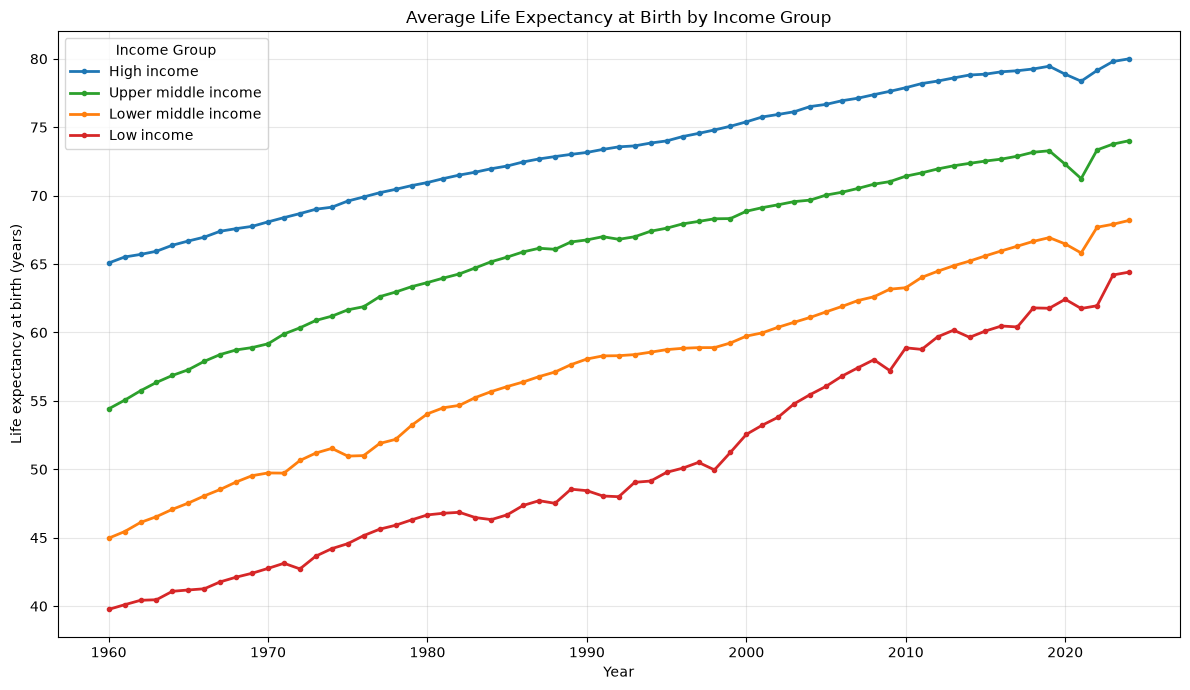

In [ ]:
# Define order and custom color mapping
order = [
    "High income",
    "Upper middle income",
    "Lower middle income",
    "Low income",
]
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Map groups to specific colors
colors = {
    "High income": default_colors[0],  # blue
    "Upper middle income": default_colors[2],  # green
    "Lower middle income": default_colors[1],  # orange
    "Low income": default_colors[3],  # red
}

# Plot time series
plt.figure(figsize=(12, 7))

for group in order:
    if group in income_group_means.index:
        plt.plot(
            [int(year) for year in years],
            income_group_means.loc[group],
            marker="o",
            markersize=3,
            linewidth=2,
            label=group,
            color=colors[group],
        )

plt.title("Average Life Expectancy at Birth by Income Group")
plt.xlabel("Year")
plt.ylabel("Life expectancy at birth (years)")

plt.legend(title="Income Group", loc="best")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 2

Create a world map where each country is color coded according to how high or low the life expectancy at birth is in 2023.

In [ ]:
# Keep 2023 data
map_df = life[["Country Name", "Country Code", "2023"]].copy()
map_df = map_df.rename(columns={"2023": "LifeExpectancy2023"})

In [ ]:
# Remove missing 2023 values
map_df = map_df.dropna(subset=["LifeExpectancy2023"])

Note: Although the above filtering step does not change the current dataframe, I have kept it in place to maintain a generalized workflow and ensure the code remains adaptable for future modifications.

In [ ]:
# Create world map
fig = px.choropleth(
    map_df,
    locations="Country Code",
    color="LifeExpectancy2023",
    hover_name="Country Name",
    color_continuous_scale="RdYlGn",
    title="Life Expectancy at Birth by Country, 2023",
    labels={"LifeExpectancy2023": "Life expectancy (years)"},
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Life expectancy<br>(years)"),
    width=1200,
    height=800,
)

fig.show()

### Task 3

**For the year 1960, rank the countries by life expectancy at birth and classify them into five buckets of roughly equal size. The buckets should be called 'Very high life expectancy', 'High life expectancy', 'Medium life expectancy', 'Low life expectancy', 'Very low life expectancy'. Repeat this for the 2023 data. Create a Sankey diagram showing from which category in 1960 countries have moved to in 2023.**

In [ ]:
# Drop countries with blank income group
life = life.dropna(subset=["IncomeGroup"])

# Keep required columns
df = life[["Country Name", "Country Code", "1960", "2023"]].copy()
df["1960"] = pd.to_numeric(df["1960"], errors="coerce")
df["2023"] = pd.to_numeric(df["2023"], errors="coerce")

I am retaining only those countries that have available data for **both** 1960 and 2023.

In [ ]:
# Keep countries with data in both years
df = df.dropna(subset=["1960", "2023"]).copy()

In [ ]:
# Create five buckets as per the task description
categories = [
    "Very low life expectancy",
    "Low life expectancy",
    "Medium life expectancy",
    "High life expectancy",
    "Very high life expectancy",
]

df["rank_1960"] = df["1960"].rank(method="first", ascending=True)
df["rank_2023"] = df["2023"].rank(method="first", ascending=True)

df["category_1960"] = pd.qcut(df["rank_1960"], q=5, labels=categories)
df["category_2023"] = pd.qcut(df["rank_2023"], q=5, labels=categories)

cats_1960, bins_1960 = pd.qcut(
    df["1960"], q=5, labels=categories, retbins=True
)
cats_2023, bins_2023 = pd.qcut(
    df["2023"], q=5, labels=categories, retbins=True
)

df["category_1960"] = cats_1960
df["category_2023"] = cats_2023

In [ ]:
# Define nodes for Sankey diagram (high income above, low below)

transition = pd.crosstab(df["category_1960"], df["category_2023"])

labels_1960 = [
    f"1960: Very high ({bins_1960[4]:.1f}-{bins_1960[5]:.1f})",
    f"1960: High ({bins_1960[3]:.1f}-{bins_1960[4]:.1f})",
    f"1960: Medium ({bins_1960[2]:.1f}-{bins_1960[3]:.1f})",
    f"1960: Low ({bins_1960[1]:.1f}-{bins_1960[2]:.1f})",
    f"1960: Very low ({bins_1960[0]:.1f}-{bins_1960[1]:.1f})",
]

labels_2023 = [
    f"2023: Very high ({bins_2023[4]:.1f}-{bins_2023[5]:.1f})",
    f"2023: High ({bins_2023[3]:.1f}-{bins_2023[4]:.1f})",
    f"2023: Medium ({bins_2023[2]:.1f}-{bins_2023[3]:.1f})",
    f"2023: Low ({bins_2023[1]:.1f}-{bins_2023[2]:.1f})",
    f"2023: Very low ({bins_2023[0]:.1f}-{bins_2023[1]:.1f})",
]

labels = labels_1960 + labels_2023

# Reorder categories accordingly (so high at top, low at bottom)
ordered_categories = [
    "Very high life expectancy",
    "High life expectancy",
    "Medium life expectancy",
    "Low life expectancy",
    "Very low life expectancy",
]

In [ ]:
# Sankey links with country hover
sources = []
targets = []
values = []
hover_texts = []

for i, cat_1960 in enumerate(ordered_categories):
    for j, cat_2023 in enumerate(ordered_categories):
        countries = df.loc[
            (df["category_1960"] == cat_1960)
            & (df["category_2023"] == cat_2023),
            "Country Name",
        ].tolist()

        if countries:
            sources.append(i)
            targets.append(5 + j)
            values.append(len(countries))
            # Show all countries in hover text
            hover_texts.append("<br>".join(countries))

# Define node colors (red -> green gradient)
node_colors = [
    "rgba(0,180,0,0.8)",  # Very high
    "rgba(100,200,0,0.8)",  # High
    "rgba(255,200,0,0.8)",  # Medium
    "rgba(255,100,0,0.8)",  # Low
    "rgba(255,0,0,0.8)",  # Very low
    "rgba(0,180,0,0.8)",  # Very high
    "rgba(100,200,0,0.8)",  # High
    "rgba(255,200,0,0.8)",  # Medium
    "rgba(255,100,0,0.8)",  # Low
    "rgba(255,0,0,0.8)",  # Very low
]

In [ ]:
# Plot Sankey diagram
fig = go.Figure(
    go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=0.5),
            label=labels,
            color=node_colors,
            customdata=[
                (
                    f"Outgoing: {sum(values[k] for k in range(len(sources)) if sources[k]==i)}"
                    if i < 5
                    else f"Incoming: {sum(values[k] for k in range(len(targets)) if targets[k]==i)}"
                )
                for i in range(len(labels))
            ],
            hovertemplate="%{label}<br>%{customdata}<extra></extra>",
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            customdata=hover_texts,
            hovertemplate="Countries (%{value:d}):<br>%{customdata}<extra></extra>",
        ),
    )
)

fig.update_layout(
    title_text="Movement of Countries Between Life Expectancy Categories: 1960 to 2023",
    font_size=20,
    font_color="black",
    width=1400,
    height=700,
)

fig.show()

The above Sankey diagram above illustrates how countries have shifted across life expectancy categories between 1960 and 2023.

- On the left-hand side, the categories are based on 1960 data, arranged from Very high at the top to Very low at the bottom.

- On the right-hand side, the categories are based on 2023 data, arranged in the same order.

The ranges shown beside each category indicate the span of life expectancy (in years) that defines that bucket. These five buckets were created using quantiles so that each group contains nearly the same number of countries.

When you hover over a particular transition flow (the connecting threads), the diagram displays:

- The names of all countries that moved from one category to another.
- The total count of countries in that flow.
